--- INFORMAÇÕES DO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2495 non-null   datetime64[ns]
 1   Open          2495 non-null   float64       
 2   High          2495 non-null   float64       
 3   Low           2495 non-null   float64       
 4   Close         2495 non-null   float64       
 5   Volume        2495 non-null   int64         
 6   Dividends     2495 non-null   float64       
 7   Stock Splits  2495 non-null   float64       
 8   Ticker        2495 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 175.6+ KB

--- VALORES NULOS ---
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Ticker          0
dtype: int64

--- ESTATÍSTICA DESCRITIVA ---


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2495,2495.000000,2495.000000,2495.000000,2495.000000,2.495000e+03,2495.000000,2495.000000
mean,2025-09-12 05:37:38.116232448,31.263420,31.595174,30.957017,31.272862,3.052256e+07,0.011804,0.000854
min,2024-09-11 00:00:00,9.742562,9.923139,9.692765,9.803686,5.449600e+06,0.000000,0.000000
25%,2025-03-14 00:00:00,15.215000,15.378413,15.069063,15.248772,2.014995e+07,0.000000,0.000000
50%,2025-09-11 00:00:00,28.237565,28.465431,28.000492,28.227026,2.672090e+07,0.000000,0.000000
75%,2026-03-16 00:00:00,42.506218,42.916007,42.021744,42.505552,3.667930e+07,0.000000,0.000000
max,2026-09-11 00:00:00,87.397575,89.119267,86.648595,87.631020,2.202628e+08,3.581771,1.100000
std,NaN,18.734779,18.948420,18.543814,18.752796,1.620685e+07,0.132566,0.030163


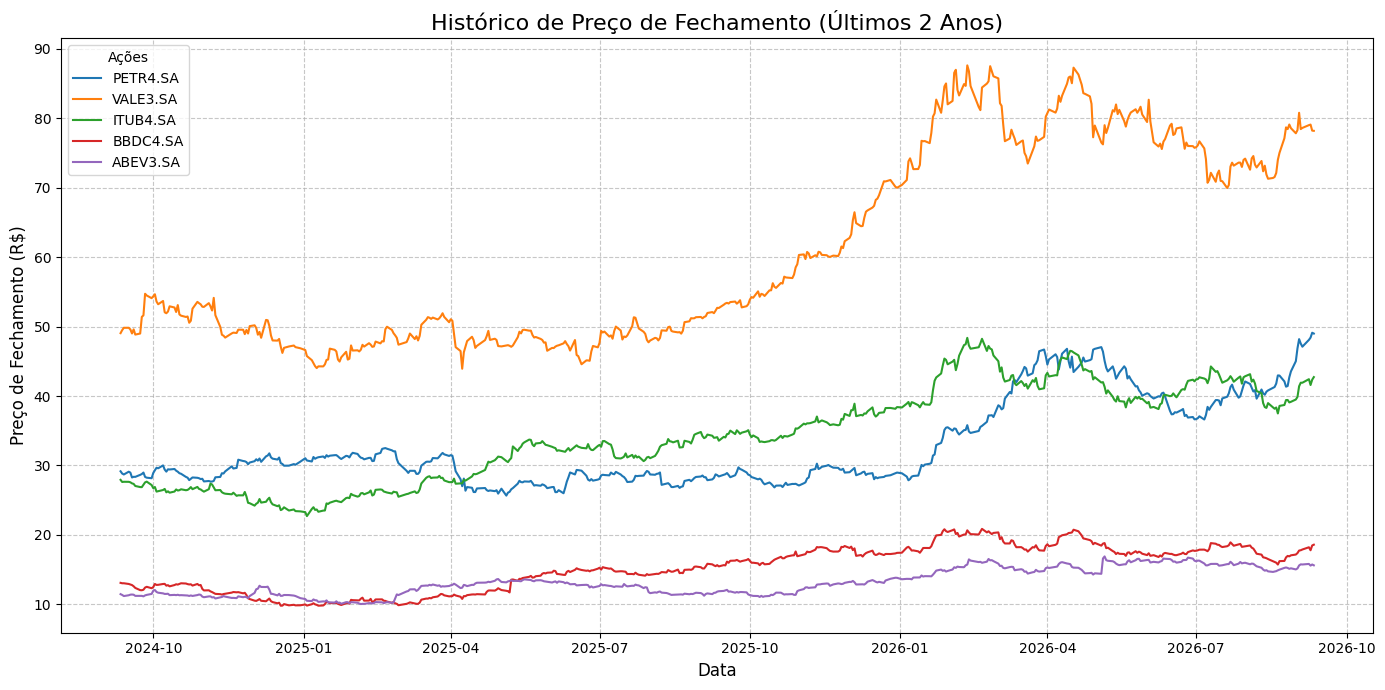

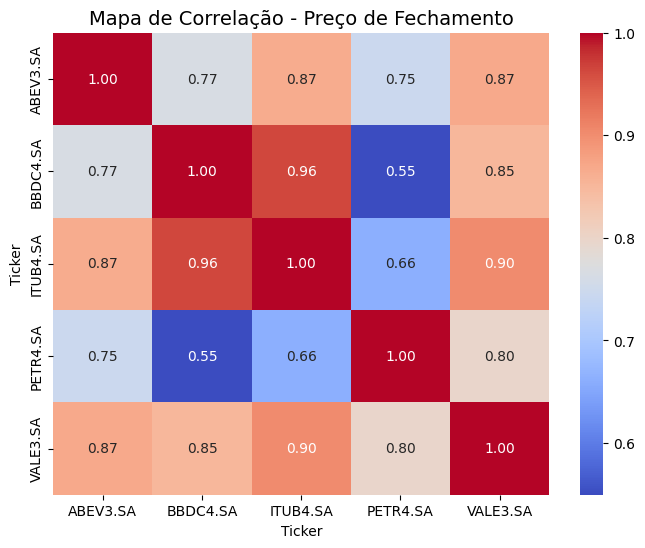

In [ ]:
"""
PROJETO DE INTELIGÊNCIA ARTIFICIAL - N1

Integrantes:
- Rafael Araujo Cabral Moreira (RA: 10441919)
- Rute Willemann (RA: 10436781)

Síntese do arquivo:
Notebook focado na Análise Exploratória de Dados (EDA) e preparação.
Realiza a leitura do dataset financeiro, verificação de nulos, análise estatística
descritiva e visualização do comportamento histórico das ações (Séries Temporais).

Histórico de Alterações:
- 13/09/2026 - Rafael Araujo Cabral Moreira - Criação do pipeline de EDA e visualização gráfica.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Leitura do Dataset
# Nota: ao rodar no Colab, certifique-se de que o CSV está na mesma pasta ou atualize o caminho
df = pd.read_csv('/content/drive/MyDrive/2026.2/IA/# Projeto/dataset_acoes_negocios.csv')
df['Date'] = pd.to_datetime(df['Date']) # Converte a coluna para o tipo Data

# 2. Informações Gerais e Qualidade dos Dados
print("--- INFORMAÇÕES DO DATASET ---")
df.info()
print("\n--- VALORES NULOS ---")
print(df.isnull().sum())

# 3. Estatística Descritiva
print("\n--- ESTATÍSTICA DESCRITIVA ---")
display(df.describe())

# 4. Visualização Gráfica: Preço de Fechamento Histórico
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Close', hue='Ticker')
plt.title('Histórico de Preço de Fechamento (Últimos 2 Anos)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço de Fechamento (R$)', fontsize=12)
plt.legend(title='Ações')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Correlação entre os preços de fechamento das diferentes ações
# Prepara os dados: pivota a tabela para ter Tickers nas colunas
df_pivot = df.pivot(index='Date', columns='Ticker', values='Close')

plt.figure(figsize=(8, 6))
sns.heatmap(df_pivot.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação - Preço de Fechamento', fontsize=14)
plt.show()